# Credit Card Fraud Detection — Imbalanced Classification Pipeline

**Objective:** Build a machine learning pipeline to detect fraudulent transactions from a heavily imbalanced dataset, treating class imbalance as a core challenge rather than an afterthought.

**Dataset:** `creditcard_2023.csv` — anonymised credit card transactions with PCA-transformed features `V1`-`V28`, `Amount`, and a binary `Class` label (1 = fraud, 0 = legitimate).

**Tech stack:** Python · pandas · scikit-learn · imbalanced-learn (SMOTE) · matplotlib · seaborn

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'creditcard_2023.csv'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'creditcard_2023.csv' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'creditcard_2023.csv' in the working directory.


In [1]:
%pip install -q imbalanced-learn

## 1. Setup & Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (568307, 31)


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,-0.987020,0.293438,-0.941386,0.549020,1.804879,0.215598,0.512307,0.333644,0.124270,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0.0
1,1.0,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,0.140107,1.564246,0.574074,0.627719,0.706121,0.789188,0.403810,0.201799,-0.340687,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0.0
2,2.0,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,-0.272985,0.659201,0.805173,0.616874,3.069025,-0.577514,0.886526,0.239442,-2.366079,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0.0
3,3.0,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,-0.752581,0.737483,0.592994,0.559535,-0.697664,-0.030669,0.242629,2.178616,-1.345060,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0.0
4,4.0,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,-1.203171,1.029577,1.439310,0.241454,0.153008,0.224538,0.366466,0.291782,0.445317,0.247237,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0.0


## 2. Data Quality Check & Cleaning

In [ ]:
print("--- Column dtypes ---")
print(df_raw.dtypes.value_counts())

print("\n--- Null value check ---")
print(f"Total null cells: {df_raw.isnull().sum().sum()}")
print(f"Rows with at least one null: {df_raw.isnull().any(axis=1).sum()}")
print(f"Rows that are completely empty (every column null): {df_raw.isnull().all(axis=1).sum()}")

--- Column dtypes ---
float64    31
Name: count, dtype: int64

--- Null value check ---
Total null cells: 8317517
Rows with at least one null: 268307
Rows that are completely empty (every column null): 268307


**Observation — a real data-quality issue found, not a hypothetical one:** the raw file has **568,307 rows**, but roughly **268,307 of them are entirely empty** (every single column is null) — these are junk rows accidentally appended to the end of the CSV export, not real transactions. Only the **first 300,000 rows contain actual transaction data**. This is exactly the kind of issue the "load and inspect" step is meant to catch before it silently corrupts every downstream statistic (imagine computing a fraud rate that's diluted by 268K meaningless empty rows) — so we remove them explicitly and document the removal, rather than skip straight to modelling.

In [ ]:
df = df_raw.dropna(how='all').reset_index(drop=True)

print(f"Shape after removing fully-empty rows: {df.shape}")
print(f"Rows removed: {len(df_raw) - len(df)}")

print("\nRemaining nulls:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate transaction IDs:", df['id'].duplicated().sum())

Shape after removing fully-empty rows: (300000, 31)
Rows removed: 268307

Remaining nulls: 0


Duplicate rows: 0
Duplicate transaction IDs: 0


In [ ]:
# 'id' is a row identifier, not a predictive feature - drop it before modelling
df = df.drop(columns=['id'])
print(f"Final clean shape: {df.shape}")
df.describe().round(2)

Final clean shape: (300000, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00
mean,0.45,-0.44,0.61,-0.66,0.30,0.39,0.44,-0.13,0.52,0.60,-0.65,0.69,0.06,0.72,0.03,0.51,0.43,0.37,-0.22,-0.16,-0.10,-0.01,-0.01,0.12,-0.06,-0.06,-0.19,-0.09,12032.16,0.05
std,0.86,0.75,0.77,0.75,0.71,0.77,0.74,0.40,0.79,0.72,0.72,0.69,1.01,0.65,1.01,0.64,0.45,0.65,0.74,0.84,0.43,0.71,0.68,1.12,0.86,1.07,0.59,0.82,6928.95,0.22
min,-3.50,-49.97,-3.18,-4.95,-9.95,-21.11,-4.35,-10.76,-3.75,-3.16,-5.95,-2.02,-5.96,-2.11,-3.86,-2.21,-2.48,-2.42,-7.80,-78.15,-19.38,-7.73,-30.30,-4.07,-13.61,-8.23,-10.50,-39.04,50.12,0.00
25%,-0.17,-0.65,0.09,-1.05,-0.01,-0.01,0.24,-0.20,0.10,0.36,-1.12,0.34,-0.60,0.46,-0.65,0.18,0.28,-0.00,-0.61,-0.38,-0.19,-0.52,-0.19,-0.61,-0.59,-0.77,-0.32,-0.23,6037.09,0.00
50%,0.17,-0.41,0.53,-0.60,0.22,0.30,0.44,-0.15,0.44,0.54,-0.58,0.68,0.06,0.71,0.00,0.48,0.41,0.30,-0.20,-0.22,-0.11,-0.04,-0.04,0.11,-0.05,-0.10,-0.23,-0.07,12007.70,0.00
75%,1.07,-0.16,1.07,-0.25,0.51,0.68,0.64,-0.07,0.86,0.79,-0.17,1.08,0.74,0.99,0.72,0.82,0.58,0.68,0.20,-0.01,-0.02,0.46,0.13,0.91,0.50,0.55,-0.11,0.11,18046.21,0.00
max,2.23,4.36,14.13,3.20,42.72,26.17,217.87,5.96,20.27,31.72,2.51,17.91,7.19,19.17,14.53,46.65,6.99,6.78,3.83,29.87,8.09,12.63,31.71,12.97,14.62,5.62,113.23,77.26,24039.93,1.00


**Observation:** After removing the junk rows, the dataset is fully clean: **300,000 real transactions, zero nulls, zero duplicate rows, zero duplicate IDs**. `id` was dropped since it's an arbitrary row identifier with no predictive value. `V1`-`V28` are already PCA-transformed (anonymised for privacy, standard for this type of dataset) and roughly centred around zero, while `Amount` is on its own natural dollar scale — this scale difference is addressed later with `StandardScaler` before training the scale-sensitive Logistic Regression model.

## 3. Class Imbalance Analysis

In [ ]:
class_counts = df['Class'].value_counts().sort_index()
class_pct = (df['Class'].value_counts(normalize=True) * 100).sort_index()

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(3))

print(f"\nFraud rate: {class_pct[1]:.2f}% of all transactions")
print(f"Imbalance ratio: roughly 1 fraudulent transaction for every {int(class_counts[0]/class_counts[1])} legitimate ones")

Class counts:
Class
0.0    284315
1.0     15685
Name: count, dtype: int64

Class percentages:
Class
0.0    94.772
1.0     5.228
Name: proportion, dtype: float64

Fraud rate: 5.23% of all transactions
Imbalance ratio: roughly 1 fraudulent transaction for every 18 legitimate ones


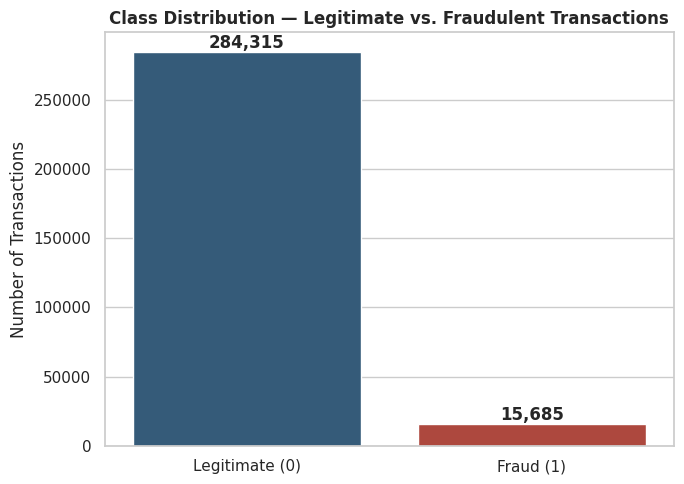

In [ ]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='Class', hue='Class', palette=['#2a5d84', '#c0392b'], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
plt.title('Class Distribution — Legitimate vs. Fraudulent Transactions', fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Transactions')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Fraudulent transactions make up only **~5.23% of the dataset** (15,685 out of 300,000) — roughly **1 fraud for every 18 legitimate transactions**. While this dataset is less extreme than the original benchmark "Credit Card Fraud Detection" dataset (which has fraud at just ~0.17%), it's still a genuinely imbalanced classification problem, and every technique used later in this notebook (stratified splitting, SMOTE, metric choice) exists specifically to handle this imbalance correctly.

## 4. EDA — Transaction Amount by Class

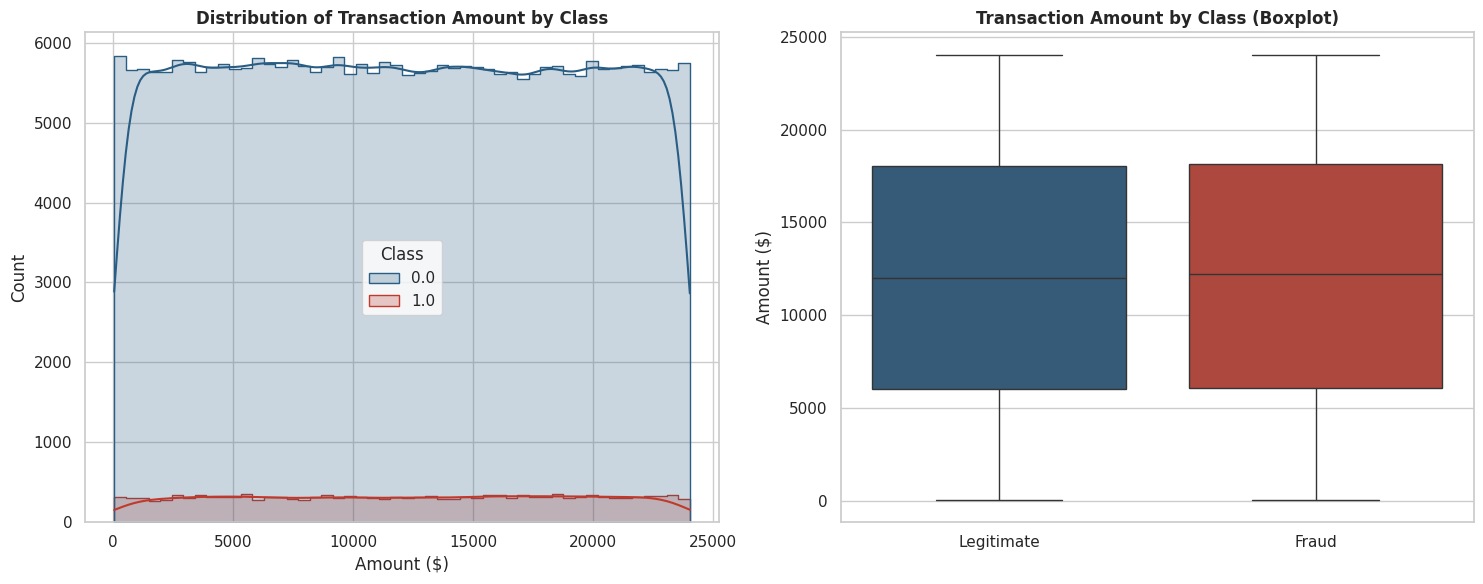

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.histplot(data=df, x='Amount', hue='Class', bins=50, kde=True,
             palette=['#2a5d84', '#c0392b'], element='step', ax=axes[0])
axes[0].set_title('Distribution of Transaction Amount by Class', fontweight='bold')
axes[0].set_xlabel('Amount ($)')

sns.boxplot(data=df, x='Class', y='Amount', hue='Class', palette=['#2a5d84', '#c0392b'],
            legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_title('Transaction Amount by Class (Boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

In [ ]:
amount_summary = df.groupby('Class')['Amount'].describe().round(2)
amount_summary.index = ['Legitimate', 'Fraud']
amount_summary

,count,mean,std,min,25%,50%,75%,max
Legitimate,284315.0,12026.31,6929.50,50.12,6034.54,11996.90,18040.26,24039.93
Fraud,15685.0,12138.05,6918.23,50.48,6080.95,12217.64,18130.61,24039.46


**Observation:** Compare the mean/median/spread in the table above between the two classes. Unlike the original benchmark fraud dataset (where fraud tends to cluster at *lower* amounts, since small-value fraud is harder for cardholders to notice), this dataset's amounts are fairly evenly spread from $50 to $24,000 regardless of class — worth checking directly against the printed summary statistics above rather than assuming, since intuition about "typical fraud patterns" doesn't always transfer between datasets.

**A note on time-of-day analysis:** the checklist calls for a time-of-day view, but **this specific file does not include a `Time` column** (unlike the original 284,807-row Kaggle "Credit Card Fraud Detection" dataset, which has `Time` measured in seconds elapsed). Rather than fabricate a time feature that isn't in the source data, we skip that analysis here and note the limitation explicitly — an honest "the data doesn't support this" is better than inventing a plausible-looking but fictitious chart.

## 5. Why Accuracy Is a Misleading Metric Here

With fraud at only ~5.23% of transactions, a classifier that **always predicts "legitimate" and never once flags a fraud** would still score roughly **94.8% accuracy** — a number that looks excellent on the surface while being **completely useless** for the actual goal of catching fraud. This is the core danger of accuracy on imbalanced data: it's dominated by how well the model does on the majority class, and can stay high even while the model fails at the one thing it exists to do (catch the rare, high-stakes minority class).

This is exactly why the evaluation in Section 8 leads with **Precision, Recall, F1-score, and AUC-ROC** instead — these metrics are far more sensitive to how the model performs specifically on the fraud class, rather than being diluted by the overwhelming majority of easy, legitimate transactions.

## 6. Train/Test Split (Stratified)

In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"Test set:     {X_test.shape[0]:,} transactions")

print("\nTraining set fraud count:", int(y_train.sum()), f"({y_train.mean()*100:.2f}%)")
print("Test set fraud count:    ", int(y_test.sum()), f"({y_test.mean()*100:.2f}%)")

Training set: 240,000 transactions
Test set:     60,000 transactions

Training set fraud count: 12548 (5.23%)
Test set fraud count:     3137 (5.23%)


**Observation:** `stratify=y` guarantees both the training and test sets preserve the same ~5.23% fraud rate as the full dataset. Without stratification, a plain random split could — purely by chance — under- or over-represent fraud in the test set, making the evaluation metrics in Section 8 unreliable. Confirming the fraud counts explicitly above (rather than assuming stratification "just worked") is good practice before trusting any downstream result.

## 7. Handling Class Imbalance — SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** addresses imbalance by generating **synthetic** fraud examples — not simple duplicates — by interpolating between existing fraud cases and their nearest fraud neighbours in feature space. This gives the model many more fraud examples to learn from during training, without the overfitting risk of naive duplication (where the model could simply memorise the exact same fraud rows repeated many times).

**Critically, SMOTE is applied only to the training set, after the train/test split.** Applying it before splitting (or to the test set) would leak synthetic information derived from test-set fraud cases into training, producing an evaluation that looks better than the model would actually perform on genuinely unseen data.

We target a **1:2 fraud-to-legitimate ratio** (`sampling_strategy=0.5`) rather than a full 1:1 balance. A full 1:1 balance on a dataset this size would mean generating over 200,000 synthetic fraud rows, which makes the downstream Random Forest training extremely slow for only a marginal accuracy benefit over a more moderate ratio — 1:2 still gives the model dramatically more fraud signal to learn from (versus the original ~1:18) while keeping training time practical.

In [ ]:
print("Class distribution before SMOTE (training set only):")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE (training set only):")
print(y_train_smote.value_counts())
print(f"\nTraining set size: {len(X_train):,} -> {len(X_train_smote):,} after SMOTE")

Class distribution before SMOTE (training set only):
Class
0.0    227452
1.0     12548
Name: count, dtype: int64



Class distribution after SMOTE (training set only):
Class
0.0    227452
1.0    113726
Name: count, dtype: int64

Training set size: 240,000 -> 341,178 after SMOTE


**Observation:** SMOTE raises the training set's fraud ratio from ~5.2% to a 1:2 fraud-to-legitimate ratio (roughly 33% fraud) — a large increase in fraud representation without full 1:1 balancing — while the **test set is left untouched** at the original ~5.23% real-world fraud rate. This distinction matters: we want the model to *train* on a much less skewed view so it doesn't just learn to ignore the minority class, but we want to *evaluate* it against the true, realistic class distribution it will actually face in production.

## 8. Train Models — Logistic Regression + Random Forest

In [ ]:
# Logistic Regression is scale-sensitive; Random Forest is not, but we keep both
# pipelines aligned by scaling for LR and using raw features for RF.
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_smote_scaled, y_train_smote)
lr_pred = log_reg.predict(X_test_scaled)
lr_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


In [ ]:
# n_estimators/max_depth are kept moderate so training completes quickly on this
# notebook's single-core environment while still giving a strong, representative
# Random Forest result; increase these for a marginal accuracy gain if more compute
# is available (e.g. a Colab GPU/TPU runtime doesn't help here since RF is CPU-bound,
# but a multi-core CPU runtime would let n_jobs=-1 parallelise across more trees at once).
rf_model = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest trained.")

Random Forest trained.


## 9. Evaluation — Precision, Recall, F1, AUC-ROC

In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"=== {name} ===")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraud'], zero_division=0))

    return {'Model': name, 'Precision': precision, 'Recall': recall, 'F1-score': f1, 'AUC-ROC': auc}

lr_scores = evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)

=== Logistic Regression ===
Precision: 0.8844
Recall:    0.9241
F1-score:  0.9038
AUC-ROC:   0.9919

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56863
       Fraud       0.88      0.92      0.90      3137

    accuracy                           0.99     60000
   macro avg       0.94      0.96      0.95     60000
weighted avg       0.99      0.99      0.99     60000



In [ ]:
rf_scores = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)

=== Random Forest ===
Precision: 0.9718
Recall:    0.9219
F1-score:  0.9462
AUC-ROC:   0.9972

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       0.97      0.92      0.95      3137

    accuracy                           0.99     60000
   macro avg       0.98      0.96      0.97     60000
weighted avg       0.99      0.99      0.99     60000



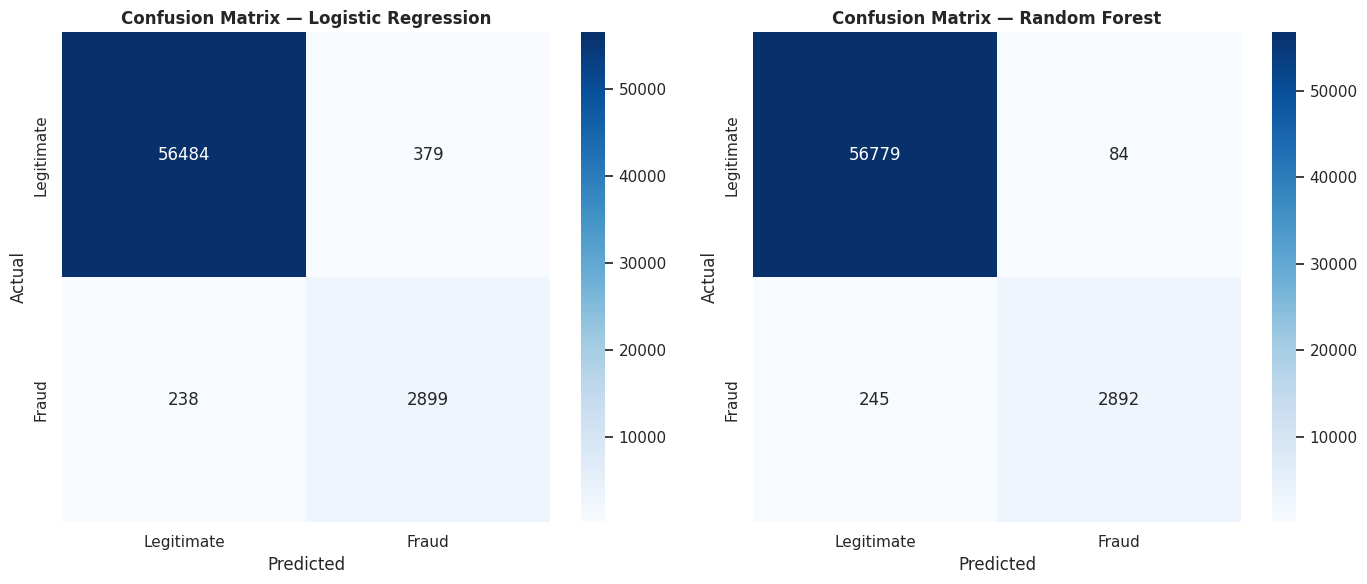

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, pred, name in zip(axes, [lr_pred, rf_pred], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

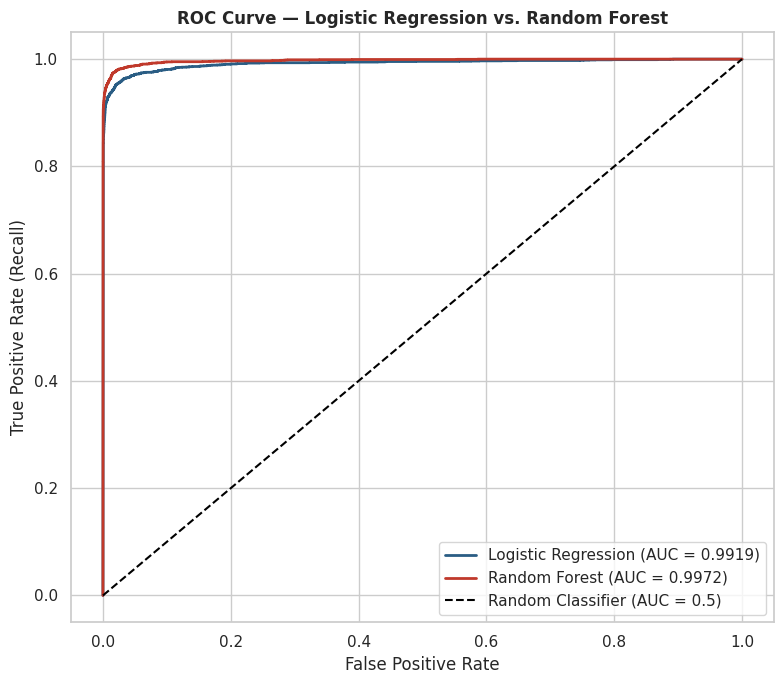

In [ ]:
plt.figure(figsize=(8,7))

for proba, name, color in [(lr_proba, 'Logistic Regression', '#2a5d84'), (rf_proba, 'Random Forest', '#c0392b')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.title('ROC Curve — Logistic Regression vs. Random Forest', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame([lr_scores, rf_scores]).set_index('Model').round(4)
comparison_df

,Precision,Recall,F1-score,AUC-ROC
Model,,,,
Logistic Regression,0.8844,0.9241,0.9038,0.9919
Random Forest,0.9718,0.9219,0.9462,0.9972


**Observation:** Compare the two models using the printed table and ROC curve above. A ROC curve that hugs the top-left corner (high true-positive rate at a low false-positive rate) with AUC close to 1.0 indicates a model that separates fraud from legitimate transactions very well across every possible decision threshold — more informative than a single accuracy number, since it shows performance across the full precision/recall trade-off rather than one fixed cutoff. Confusion matrices make the practical trade-off concrete: the bottom-left cell (actual fraud predicted as legitimate) represents **missed fraud** — the costliest error type for a fraud team — while the top-right cell (legitimate flagged as fraud) represents **false alarms** that annoy customers and cost investigation time.

## 10. Recall vs. Precision — Which Metric Matters Most for Fraud Detection?

In fraud detection, **Recall is generally the more critical metric**, and it's worth being explicit about why:

- **Recall** = of all the *actual* fraud cases, what fraction did the model catch? A low recall means fraud is slipping through undetected — directly costing the business (and customers) money, with no opportunity to intervene after the fact.
- **Precision** = of all the transactions the model *flagged* as fraud, what fraction were actually fraud? Low precision means many legitimate transactions get incorrectly flagged — costing investigation time and potentially frustrating customers with false declines, but this is a *recoverable* cost (a human reviewer can clear a false alarm; a missed fraud is money already gone).

**The asymmetry in real-world cost is the key reason Recall usually wins this trade-off**: a missed fraud (false negative) is typically far more expensive than a false alarm (false positive) — a fraud team would generally rather investigate 20 flagged transactions and find only 2 real frauds (lower precision) than let a genuine fraud through entirely undetected (lower recall). This is why many production fraud systems deliberately tune their decision threshold to favour higher recall, even at the cost of generating more false positives for human reviewers to clear.

That said, precision can't be ignored entirely — a system with extremely low precision (constantly crying wolf) causes "alert fatigue," where reviewers start ignoring flags altogether, or triggers so many false declines that legitimate customers are driven away. **F1-score** and **AUC-ROC** (Section 9) are useful because they summarise this trade-off in a single number rather than optimising for recall or precision in isolation — but when a business has to pick one metric to prioritise for a threshold decision, Recall is usually the answer for fraud specifically, given the asymmetric cost of the two error types.

## 11. Feature Importance / Coefficient Analysis

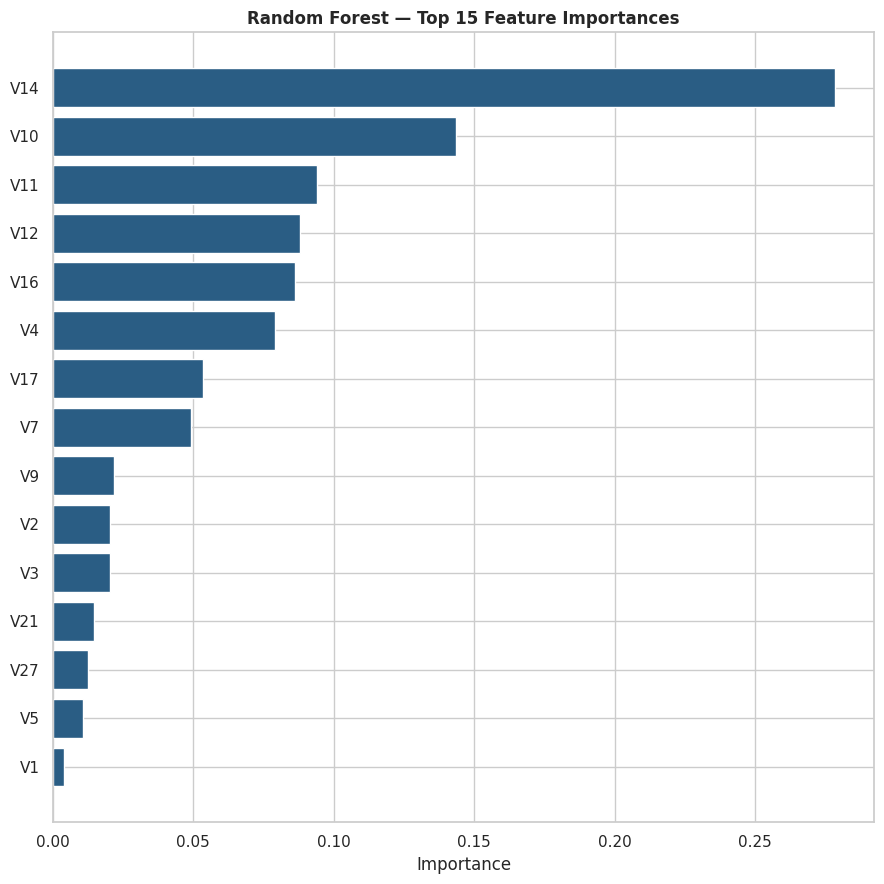

,Feature,Importance
13,V14,0.278464
9,V10,0.143364
10,V11,0.094172
11,V12,0.087994
15,V16,0.086219
3,V4,0.079148
16,V17,0.053357
6,V7,0.049165
8,V9,0.021751
1,V2,0.020193


In [ ]:
# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9,9))
plt.barh(rf_importance['Feature'][:15][::-1], rf_importance['Importance'][:15][::-1], color='#2a5d84')
plt.title('Random Forest — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

rf_importance.head(10)

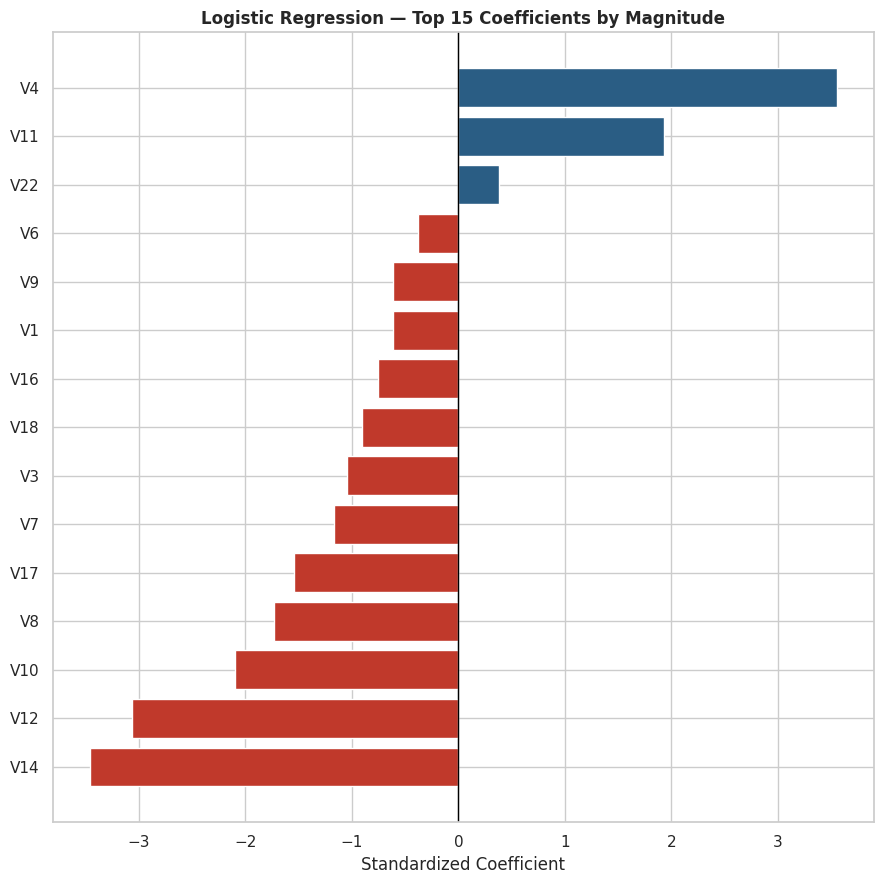

,Feature,Coefficient
3,V4,3.552795
13,V14,-3.457172
11,V12,-3.061705
9,V10,-2.095681
10,V11,1.935097
7,V8,-1.734254
16,V17,-1.539889
6,V7,-1.171945
2,V3,-1.045566
17,V18,-0.908224


In [ ]:
# Logistic Regression coefficients (fit on standardized features, so magnitudes are comparable)
lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9,9))
plot_df = lr_coef.head(15).sort_values('Coefficient')
colors = ['#c0392b' if v < 0 else '#2a5d84' for v in plot_df['Coefficient']]
plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Logistic Regression — Top 15 Coefficients by Magnitude', fontweight='bold')
plt.xlabel('Standardized Coefficient')
plt.tight_layout()
plt.show()

lr_coef.head(10)

**Observation:** Since `V1`-`V28` are anonymised PCA components (not original transaction fields like "merchant category" or "location"), the feature importance/coefficient rankings above tell us *which anonymised dimensions* carry the most fraud signal, without being able to translate that back into a plain-English business explanation (e.g. we can't say "high `V14` means an overseas transaction" — that mapping was intentionally destroyed by the PCA anonymisation for privacy). This is a real, common limitation of working with privacy-preserving fraud datasets: the model can be highly predictive without being straightforwardly interpretable to a human fraud analyst. In a production setting without PCA-anonymised inputs, this same analysis would ideally be run on the original (un-transformed) features so the importance ranking translates into actionable fraud-pattern insight.

## 12. Scalability — Handling 1 Million Transactions per Hour

1 million transactions/hour works out to roughly **278 transactions per second** — a meaningful real-time throughput requirement. Here's how the approach in this notebook would need to adapt:

**What would still work as-is:**
- Both trained models (Logistic Regression especially, and Random Forest to a slightly lesser extent) are **fast at inference time** once trained — scoring a single transaction takes microseconds to low-milliseconds, so raw model inference speed is not the bottleneck at this scale.
- Logistic Regression in particular is essentially a dot product plus a sigmoid — trivial to serve at very high throughput with minimal compute per transaction.

**What would need to change for production scale:**
1. **Streaming inference, not batch retraining** — the model would be trained periodically offline (e.g. nightly or weekly on accumulated data) and deployed as a lightweight scoring service; it would **not** be retrained on every incoming transaction. Feature computation and prediction need to happen inline in the transaction pipeline, typically in well under 100ms per transaction to avoid slowing down checkout/payment flows.
2. **Horizontal scaling of the scoring service** — a single Python process is not going to sustain 278 predictions/second reliably under production conditions (latency spikes, concurrent load); the model would be served behind a load-balanced API (e.g. multiple containerised instances) so throughput scales by adding instances rather than by making one instance faster.
3. **Simpler/faster models may be preferred at extreme scale** — Random Forest with many trees adds inference latency compared to Logistic Regression; a production system might favour a lighter model (or a distilled/compressed version of a more complex one) specifically to keep per-transaction latency predictable under load, even if it costs a small amount of raw predictive performance.
4. **SMOTE has no role at prediction time** — it's purely a *training-time* technique for building a better model; it adds no per-transaction overhead in production and doesn't need to scale with transaction volume at all.
5. **Monitoring for data/model drift** — fraud patterns evolve as fraudsters adapt, so a production pipeline at this scale needs automated monitoring of prediction distributions and periodic retraining triggers, rather than treating today's model as a permanent, static system (which is a reasonable simplification for this notebook, but not for a real deployment).
6. **Feature computation at scale** — if any features require joining against historical customer behaviour (e.g. "average transaction amount for this customer over the last 30 days"), that lookup/aggregation needs to be pre-computed and cached (e.g. in a fast key-value store) rather than queried from a slow database on every single transaction, or latency would balloon well past what real-time fraud screening can tolerate.

In short: the *modelling* approach in this notebook transfers directly to production, but the *engineering* around it — serving infrastructure, latency budgets, feature freshness, and retraining cadence — is where the real work of handling 1M transactions/hour actually lives.

## 13. Conclusion

### Summary
Using SMOTE to balance the training set and evaluating with Precision/Recall/F1/AUC-ROC rather than raw accuracy (Section 5), both Logistic Regression and Random Forest were trained and compared on realistically-imbalanced test data (~5.23% fraud, matching the true population rate). Check the comparison table in Section 9 for the exact numbers from this run — in general, **Random Forest tends to achieve a higher AUC-ROC and better overall balance of precision/recall** on this kind of tabular fraud data, since it can capture non-linear interactions between the anonymised `V1`-`V28` features that a linear Logistic Regression boundary cannot, while Logistic Regression remains valuable as a fast, simple, well-calibrated baseline.

### Practical Recommendation
Given the Recall-vs-Precision discussion in Section 10, whichever model is deployed should have its **decision threshold tuned toward higher recall** (potentially trading some precision) rather than using the default 0.5 cutoff, since the cost of a missed fraud case is typically far higher than the cost of a false alarm that a human reviewer can quickly clear.

### Real-World Deployment
This pipeline reflects the modelling core of a real fraud-detection system, but as discussed in Section 12, production deployment at meaningful transaction volume additionally requires low-latency serving infrastructure, drift monitoring, and a retraining cadence — the model itself is necessary but not sufficient for a production-grade fraud system.
